In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

age: Displays the age of the individual.

sex: Displays the gender of the individual using the following format : 1 = male 0 = female

cp- Chest-pain type: displays the type of chest-pain experienced by the individual using the following format : 0 = typical angina 1 = atypical angina 2 = non — anginal pain 3 = asymptotic

trestbps- Resting Blood Pressure: displays the resting blood pressure value of an individual in mmHg (unit). anything above 130-140 is typically cause for concern.

chol- Serum Cholestrol: displays the serum cholesterol in mg/dl (unit)

fbs- Fasting Blood Sugar: compares the fasting blood sugar value of an individual with 120mg/dl. If fasting blood sugar > 120mg/dl then : 1 (true) else : 0 (false) '>126' mg/dL signals diabetes

restecg- Resting ECG : displays resting electrocardiographic results 0 = normal 1 = having ST-T wave abnormality 2 = left ventricular hyperthrophy

thalach- Max heart rate achieved : displays the max heart rate achieved by an individual.

exang- Exercise induced angina : 1 = yes 0 = no

oldpeak- ST depression induced by exercise relative to rest: displays the value which is an integer or float.

slope- Slope of the peak exercise ST segment : 0 = upsloping: better heart rate with excercise (uncommon) 1 = flat: minimal change (typical healthy heart) 2 = downsloping: signs of unhealthy heart

ca- Number of major vessels (0–3) colored by flourosopy : displays the value as integer or float.

thal : Displays the thalassemia : 1,3 = normal 6 = fixed defect 7 = reversible defect: no proper blood movement when excercising

target : Displays whether the individual is suffering from heart disease or not : 1 = yes 0 = no

In [2]:
df=pd.read_csv('heart disease classification dataset.csv')

In [3]:
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [4]:
df.isnull().sum()

Unnamed: 0    0
age           0
sex           0
cp            0
trestbps      4
chol          1
fbs           0
restecg       0
thalach       5
exang         0
oldpeak       0
slope         0
ca            0
thal          0
target        0
dtype: int64

In [5]:
print(f"Cholestrol missing value:{df[df['chol'].isnull()].index}")
print(f"trestbps missing value:{df[df['trestbps'].isnull()].index}")
print(f"thalach missing value:{df[df['thalach'].isnull()].index}")

Cholestrol missing value:Index([261], dtype='int64')
trestbps missing value:Index([4, 15, 50, 301], dtype='int64')
thalach missing value:Index([90, 135, 177, 216, 297], dtype='int64')


In [6]:
##finding indexes of missing data to understand the handling of null data
print(df[df.index==261])
print(df.loc[[4, 15, 50, 301]])


     Unnamed: 0  age   sex  cp  trestbps  chol  fbs  restecg  thalach  exang  \
261         261   52  male   0     112.0   NaN    0        1    160.0      0   

     oldpeak  slope  ca  thal target  
261      0.0      2   1     2     no  
     Unnamed: 0  age     sex  cp  trestbps   chol  fbs  restecg  thalach  \
4             4   57  female   0       NaN  354.0    0        1    163.0   
15           15   50  female   2       NaN  219.0    0        1    158.0   
50           50   51  female   2       NaN  256.0    0        0    149.0   
301         301   57    male   0       NaN  131.0    0        1    115.0   

     exang  oldpeak  slope  ca  thal target  
4        1      0.6      2   0     2    yes  
15       0      1.6      1   0     2    yes  
50       0      0.5      2   0     2    yes  
301      1      1.2      1   1     3     no  


## Handling Null Values

In [7]:
## Dropping serial number column

In [8]:
df=df.drop('Unnamed: 0',axis=1)

In [9]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [10]:
## Now the best solution is to fill null values with median of their respective columns

In [11]:
df["trestbps"] = df["trestbps"].fillna(df["trestbps"].median())
df["chol"] = df["chol"].fillna(df["chol"].median())
df["thalach"] = df["thalach"].fillna(df["thalach"].median())

In [12]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [13]:
## now no values is missing

## EDA(Exploratory Data Analysis)

In [14]:
df["target"].value_counts() ## To check class balance of target

target
yes    165
no     138
Name: count, dtype: int64

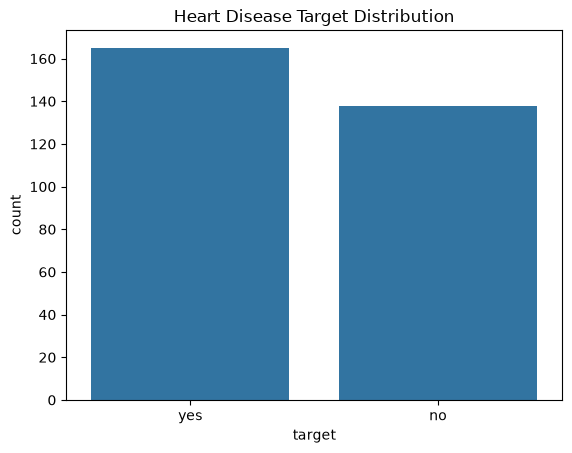

In [15]:
sns.countplot(x="target", data=df)
plt.title("Heart Disease Target Distribution")
plt.show()

In [16]:
## as we can see class is more or less balanced

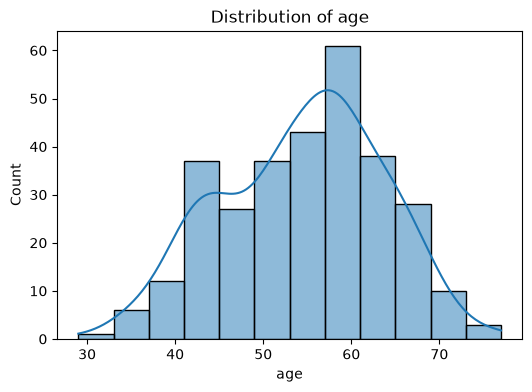

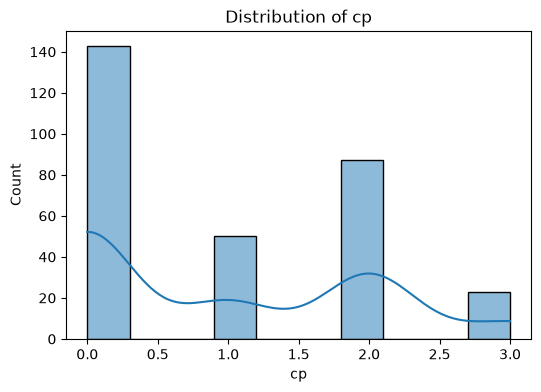

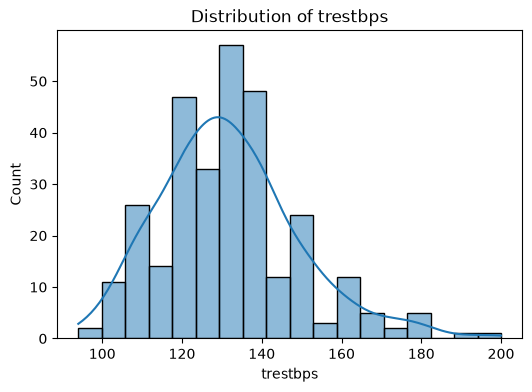

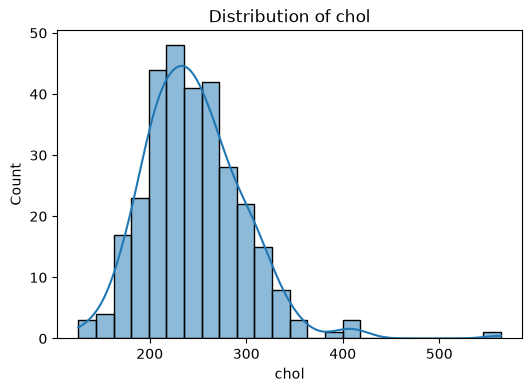

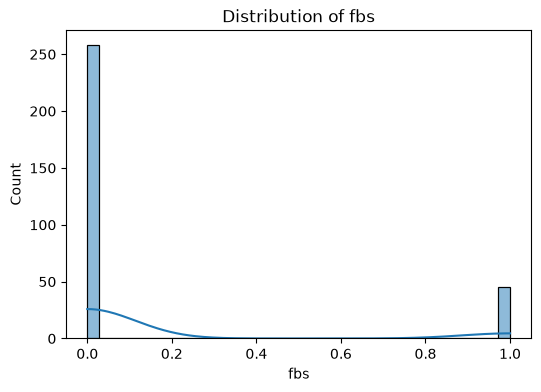

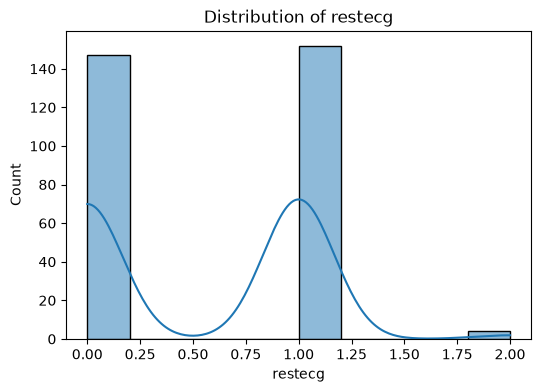

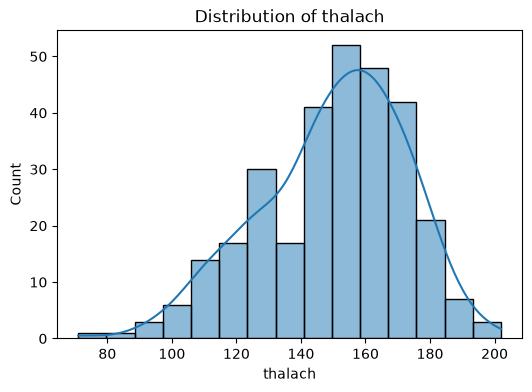

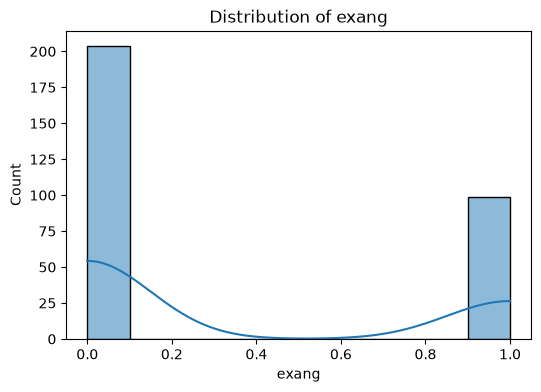

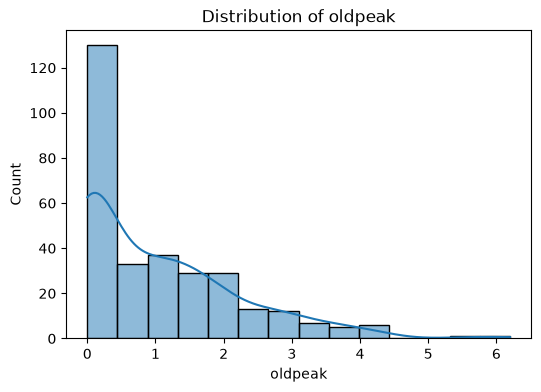

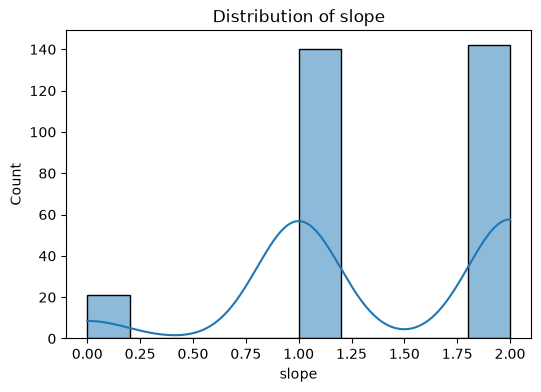

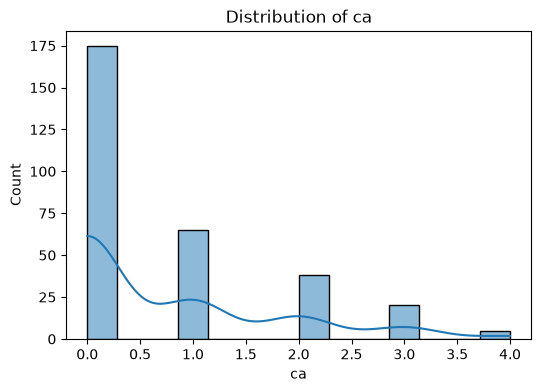

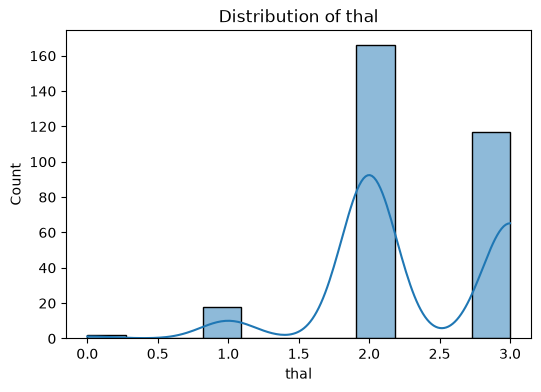

In [17]:
##
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [18]:
print(df[df['chol'] > 450].index) ## potential outliers

Index([85], dtype='int64')


In [19]:
df[df['chol'] > 450] ## Since our dataset is small and value of 500 medically possible we will not remove it

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
85,67,female,2,115.0,564.0,0,0,160.0,0,1.6,1,0,3,yes


In [20]:
df.nlargest(3,'trestbps') ## as values close no outliers

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
223,56,female,0,200.0,288.0,1,0,133.0,1,4.0,0,2,3,no
248,54,male,1,192.0,283.0,0,0,195.0,0,0.0,2,1,3,no
110,64,female,0,180.0,325.0,0,1,154.0,1,0.0,2,0,2,yes


In [21]:
## Now restcg
df.nlargest(7,'restecg') # since 4 value have 2 restecg we will also not remove it

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
144,76,female,2,140.0,197.0,0,2,116.0,0,1.1,1,0,2,yes
266,55,female,0,180.0,327.0,0,2,117.0,1,3.4,1,0,2,no
289,55,female,0,128.0,205.0,0,2,130.0,1,2.0,1,1,3,no
291,58,male,0,114.0,318.0,0,2,140.0,0,4.4,0,3,1,no
1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,57,female,0,130.0,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [22]:
df[df['thal']<1].index 

Index([48, 281], dtype='int64')

In [23]:
df.nsmallest(5,'thal')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
48,53,female,2,128.0,216.0,0,0,115.0,0,0.0,2,0,0,yes
281,52,male,0,128.0,204.0,1,1,156.0,1,1.0,1,0,0,no
0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
5,57,male,0,140.0,192.0,0,1,148.0,0,0.4,1,0,1,yes
62,52,male,3,118.0,186.0,0,0,190.0,0,0.0,1,0,1,yes


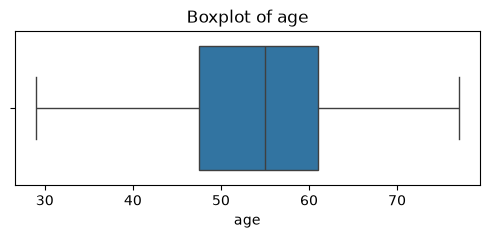

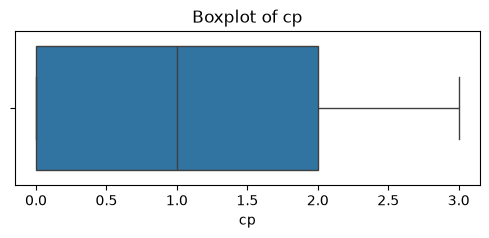

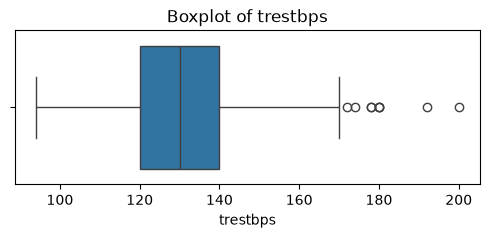

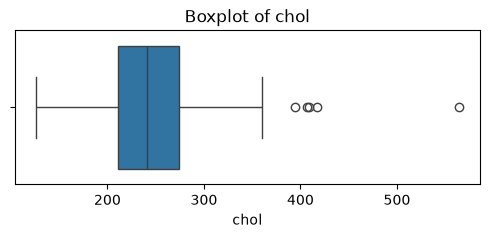

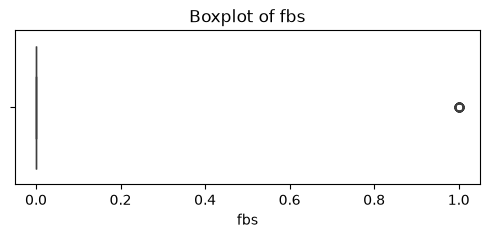

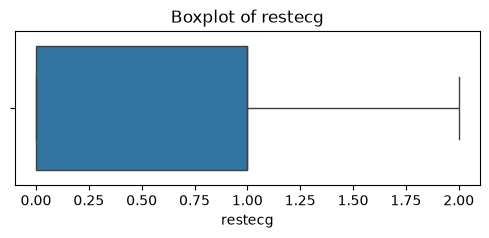

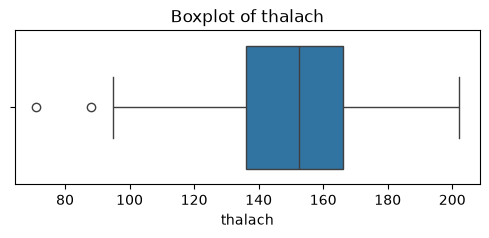

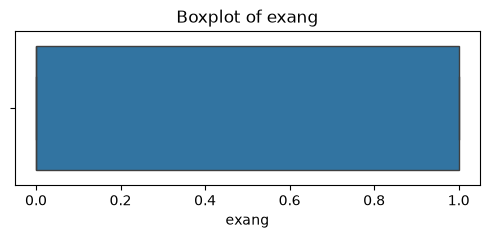

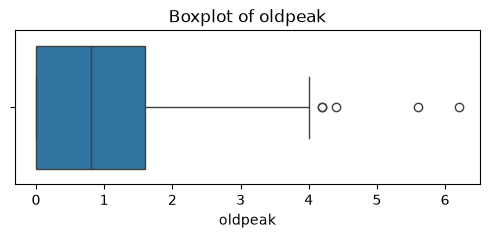

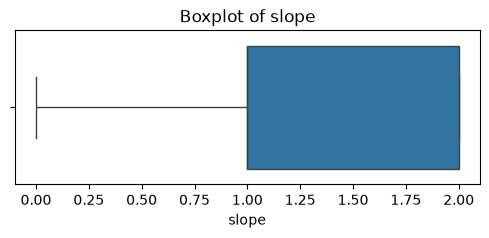

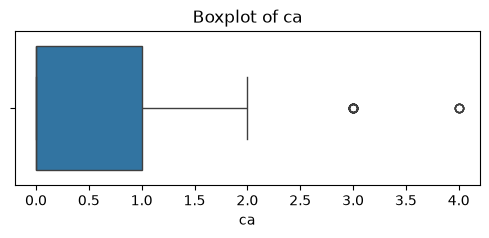

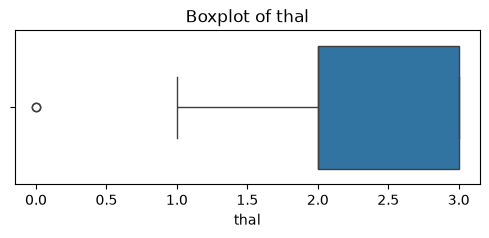

In [24]:
## For outliers checking by graph
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### Now we know outliers but we will not remove them as our dataset is too small in version 1 but with each further version we will keep removing outliers and checking results if model performs better we will update the model version else not

## Correlation heatmap before and after Encoding data

In [25]:
df.dtypes

age           int64
sex          object
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalach     float64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target       object
dtype: object

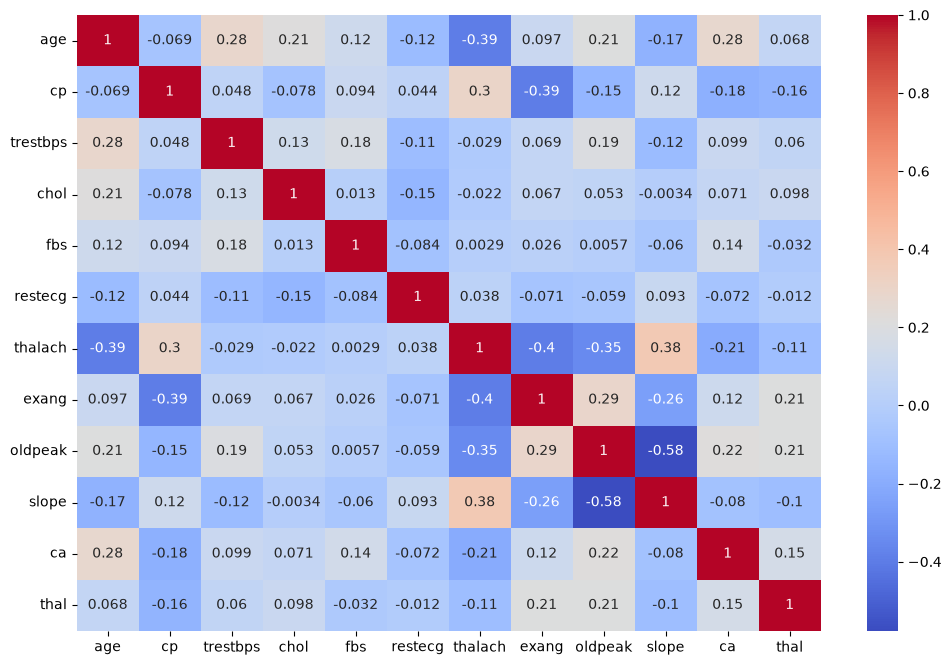

In [26]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [27]:
## One hot encoding

In [28]:
df = pd.get_dummies(df, columns=['sex'], drop_first=True)

In [29]:
df['target'] = df['target'].map({
    'no': 0,
    'yes': 1
})

In [30]:
df.head()

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,sex_male
0,63,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1,True
1,37,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,1,True
2,41,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1,False
3,56,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,1,True
4,57,0,130.0,354.0,0,1,163.0,1,0.6,2,0,2,1,False


In [31]:
df = df.replace({True: 1, False: 0})

C:\Users\ASTITVA MISHRA\AppData\Local\Temp\ipykernel_27368\3074727906.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True: 1, False: 0})


In [32]:
df.head()

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,sex_male
0,63,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1,1
1,37,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,1,1
2,41,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1,0
3,56,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,1,1
4,57,0,130.0,354.0,0,1,163.0,1,0.6,2,0,2,1,0


<Axes: >

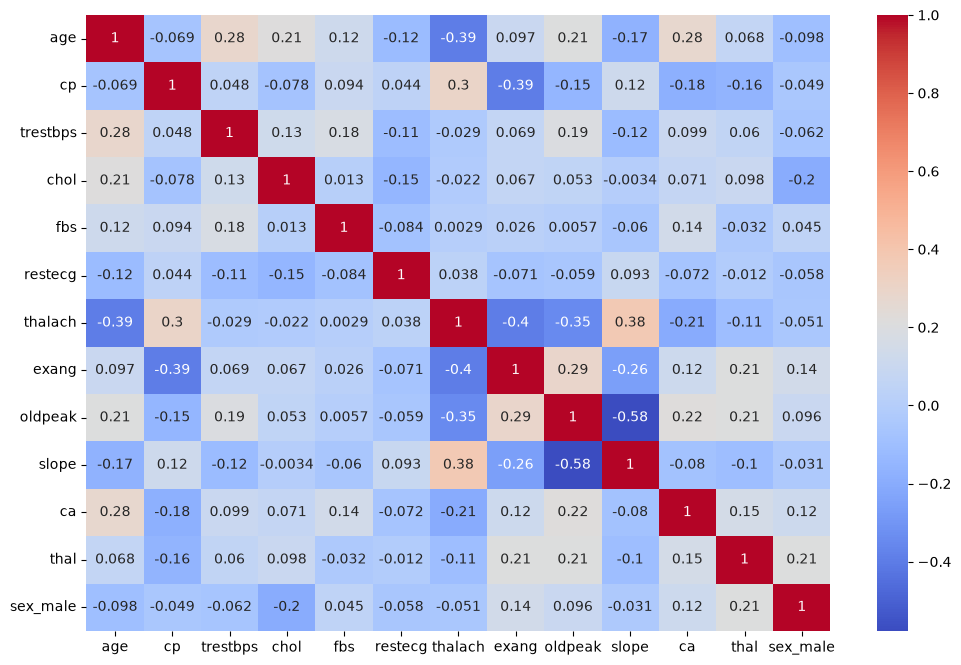

In [33]:
df_corr=df.drop('target',axis=1)
plt.figure(figsize=(12,8))
sns.heatmap(df_corr.corr(),cmap='coolwarm',annot=True)

### Now we got relation between all features we will try to research if combining two or more features can get us more correlated feature to improve accuracy

## Feature Vs target Analysis

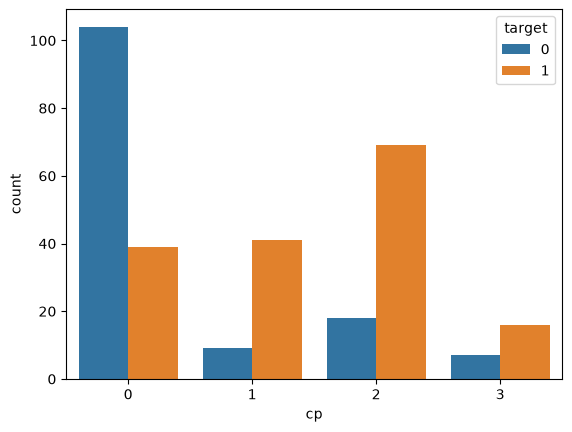

In [34]:
sns.countplot(x='cp', hue='target', data=df)
plt.show()

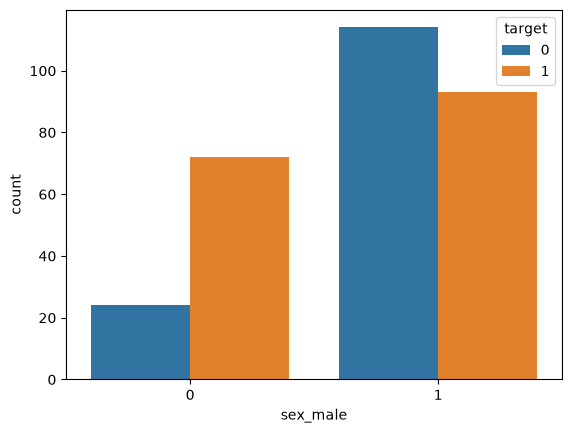

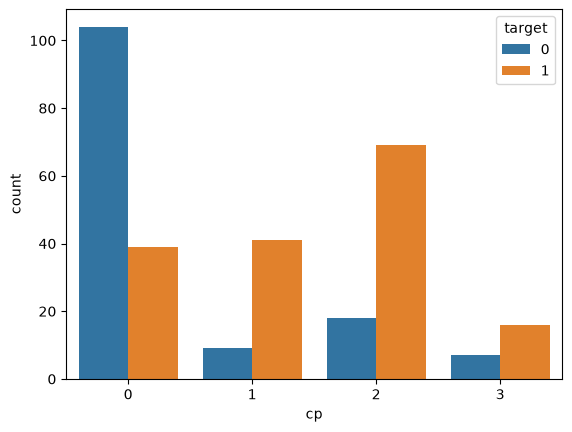

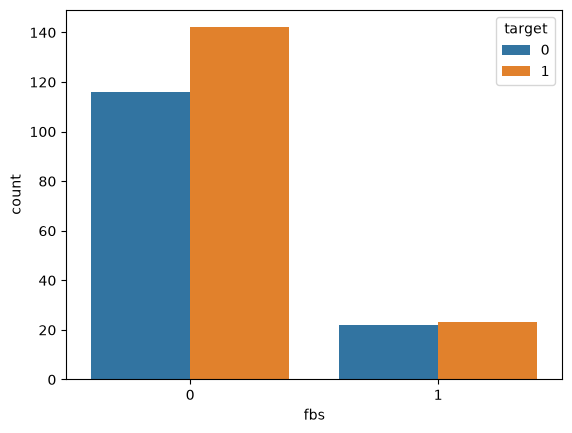

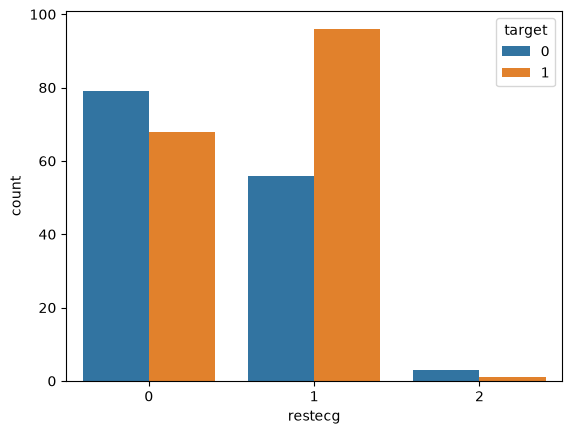

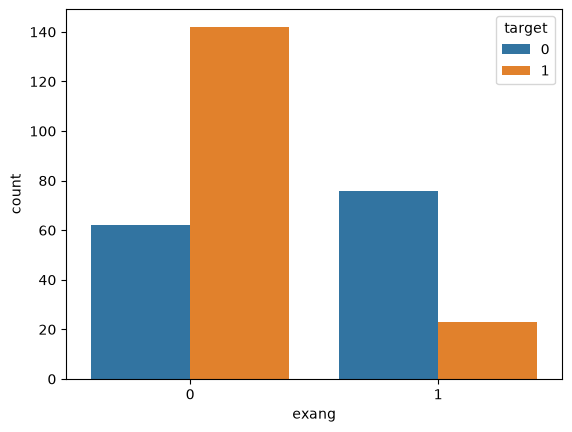

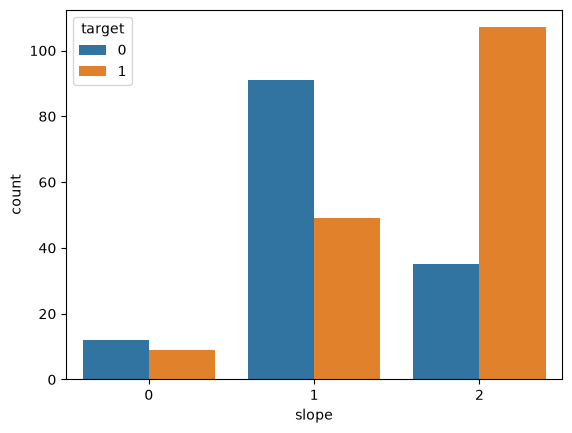

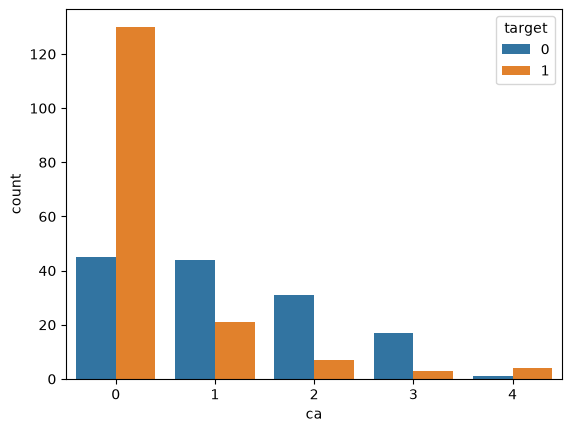

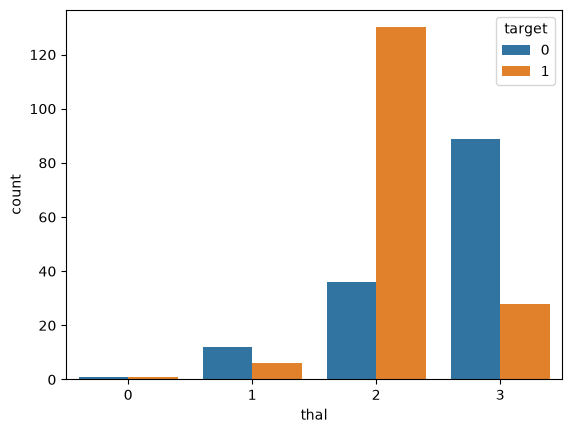

In [35]:
categorical_cols = ['sex_male','cp','fbs','restecg','exang','slope','ca','thal']

for col in categorical_cols:
    sns.countplot(x=col, hue='target', data=df)
    plt.show()

In [36]:
df[df['thal']<1].index ## not a good attribute below 1 to get to predict target

Index([48, 281], dtype='int64')

## Feature Engineering

<!-- ## Feature Engineering to get better correlation between columns/feature -->

In [37]:
# df['age_group'] = pd.cut(
#     df['age'],
#     bins=[0, 40, 55, 70, 100],
#     labels=['young', 'mid', 'old', 'very_old']
# )

In [38]:
# df['high_chol'] = (df['chol'] > 240).astype(int)

In [39]:
# df['high_bp'] = (df['trestbps'] > 140).astype(int)

In [40]:
# df['stress_score'] = (
#     df['exang'] +
#     (df['cp'] == 3).astype(int) +
#     (df['thalach'] < df['thalach'].median()).astype(int)
# )

In [41]:
# df['oldpeak_high'] = (df['oldpeak'] > 2).astype(int)

In [42]:
# plt.figure(figsize=(12,8))
# sns.heatmap(df.corr(numeric_only=True),annot=True, cmap='coolwarm')
# plt.show()

## In version 1 we will not use Feature engineering

## Train_Test_Split

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X=df.drop('target',axis=1)
y=df['target']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

# Model Selection

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from xgboost import XGBClassifier
import optuna

In [47]:
# import os
# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [48]:
# import torch
# from torch import nn  
## for later version trained with neural network

In [49]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

## Cross Validation

In [50]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [51]:
model={
    "Logistic Regression":LogisticRegression(max_iter=5000,random_state=42),
    "Random Forest Classifier":RandomForestClassifier(n_estimators=100,random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
}

### Model Training

In [52]:
results=[]
for name,model in model.items():
    accuracy=cross_val_score(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring='accuracy'
    )
    
    precision=cross_val_score(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring='precision'
    )
    recall = cross_val_score(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring='recall'
    )
    f1 = cross_val_score(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring='f1'
    )

    roc_auc = cross_val_score(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring='roc_auc'
    )
    results.append({
        "Model": name,
        "Accuracy": accuracy.mean(),
        "Precision": precision.mean(),
        "Recall": recall.mean(),
        "F1 Score": f1.mean(),
        "ROC AUC": roc_auc.mean()
    })

In [53]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': np.float64(0.8136904761904763),
  'Precision': np.float64(0.8031966735526245),
  'Recall': np.float64(0.8703703703703702),
  'F1 Score': np.float64(0.8352287318455179),
  'ROC AUC': np.float64(0.8876068376068377)},
 {'Model': 'Random Forest Classifier',
  'Accuracy': np.float64(0.8095238095238095),
  'Precision': np.float64(0.8143223443223443),
  'Recall': np.float64(0.8478632478632478),
  'F1 Score': np.float64(0.8301397341119288),
  'ROC AUC': np.float64(0.8878982128982129)},
 {'Model': 'AdaBoost',
  'Accuracy': np.float64(0.8140306122448979),
  'Precision': np.float64(0.8299156327543425),
  'Recall': np.float64(0.833048433048433),
  'F1 Score': np.float64(0.8303739532948459),
  'ROC AUC': np.float64(0.8761978761978761)},
 {'Model': 'XGBoost',
  'Accuracy': np.float64(0.8017857142857142),
  'Precision': np.float64(0.8142685185185184),
  'Recall': np.float64(0.8330484330484331),
  'F1 Score': np.float64(0.8223440092023022),
  'ROC AUC': 

In [54]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["ROC AUC", "Recall"],
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Random Forest Classifier,0.809524,0.814322,0.847863,0.830140,0.887898
0,Logistic Regression,0.813690,0.803197,0.870370,0.835229,0.887607
2,AdaBoost,0.814031,0.829916,0.833048,0.830374,0.876198
3,XGBoost,0.801786,0.814269,0.833048,0.822344,0.866097


In [55]:
## As expected AdaBoost and Xgboost are less useful to this dataset as dataset is too small

We will pick two best models out of results and use optuna there which are Random Forest and Logistic Regression

But lets scale the data and use logistic regression again as it is sensitive to magnitude 

## Scaling Data for Logistic Regression

In [56]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import cross_validate

In [57]:
# scale=StandardScaler()

In [58]:
# X_train_scale=scale.fit_transform(X_train)
# X_test_scale=scale.fit_transform(X_test)
# scoring1=['accuracy','precision','recall','f1','roc_auc']

In [59]:
# scores=cross_validate(
#     estimator=LogisticRegression(max_iter=5000,random_state=42),
#     X=X_train_scale,
#     y=y_train,
#     cv=cv,
#     scoring=scoring1     
# )

In [60]:
# scores

In [61]:
# print("Accuracy :", scores['test_accuracy'].mean())
# print("Precision:", scores['test_precision'].mean())
# print("Recall   :", scores['test_recall'].mean())
# print("F1 Score :", scores['test_f1'].mean())
# print("ROC AUC  :", scores['test_roc_auc'].mean())

### Feature scaling was evaluated for Logistic Regression. Performance metrics remained nearly unchanged, suggesting the dataset's feature distributions were already suitable for model optimization and scaling provided limited additional benefit.

## Tuning Hyperparameters Using Optuna

In [62]:
import optuna
from sklearn.model_selection import cross_validate

### For Random Forest

In [63]:

scoring1=['accuracy','precision','recall','f1','roc_auc']
def objective(trial):
    
    n_estimators = trial.suggest_int(
        "n_estimators",
        50,
        500
    )

    max_depth = trial.suggest_int(
        "max_depth",
        2,
        20
    )

    min_samples_split = trial.suggest_int(
        "min_samples_split",
        2,
        20
    )

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )
    scores=cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring1     
    )
    return scores['test_roc_auc'].mean()

In [64]:
study = optuna.create_study(
    direction='maximize'
)

[I 2026-07-04 13:06:01,352] A new study created in memory with name: no-name-4dd10d3c-38a8-4164-86fd-880cb37860bd


In [ ]:
study.optimize(
    objective,
    n_trials=100
)

In [80]:
print(study.best_params)

{'n_estimators': 276, 'max_depth': 11, 'min_samples_split': 13}


In [87]:
best_rf=RandomForestClassifier(n_estimators=83,max_depth=12,min_samples_split=10,random_state=42) ## estimators from the previous study

In [88]:
best_rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",83
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [89]:
y_pred=best_rf.predict(X_test)
y_pred_proba=best_rf.predict_proba(X_test)[:,1]

In [90]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [91]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_proba))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.8524590163934426
Precision: 0.8
Recall   : 0.9696969696969697
F1 Score : 0.8767123287671232
ROC AUC  : 0.9155844155844155

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.71      0.82        28
           1       0.80      0.97      0.88        33

    accuracy                           0.85        61
   macro avg       0.88      0.84      0.85        61
weighted avg       0.87      0.85      0.85        61


Confusion Matrix:

[[20  8]
 [ 1 32]]


The model is optimized for medical safety by prioritizing recall. It achieves 0.97 recall, ensuring minimal false negatives, which is critical in heart attack prediction. The ROC-AUC of 0.91 indicates strong discrimination capability between positive and negative cases.

### For Logistic Regression

In [72]:
def objective_lr(trial):

    C = trial.suggest_float(
        "C",
        0.0001,
        100,
        log=True
    )

    model = LogisticRegression(
        C=C,
        max_iter=5000,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc'
    ).mean()

    return score

In [ ]:
study_lr = optuna.create_study(
    direction='maximize'
)

study_lr.optimize(
    objective_lr,
    n_trials=100
)

In [74]:
## NO IMPROVEMENT OVERALL but lets train a model with best params to see if Other metrics improver or not

In [75]:
print(study_lr.best_params)

{'C': 0.16996023657890022}


In [ ]:
best_lg=LogisticRegression(C=0.18188777406351125,max_iter=5000,random_state=42) ##from a previous run

In [77]:
best_lg.fit(X_train,y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.18188777406351125
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem

In [78]:
y_pred_lg=best_lg.predict(X_test)
y_pred_proba_lg=best_lg.predict_proba(X_test)[:,1]

In [79]:
print("Accuracy :", accuracy_score(y_test, y_pred_lg))
print("Precision:", precision_score(y_test, y_pred_lg))
print("Recall   :", recall_score(y_test, y_pred_lg))
print("F1 Score :", f1_score(y_test, y_pred_lg))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_proba_lg))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lg))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lg))

Accuracy : 0.7868852459016393
Precision: 0.75
Recall   : 0.9090909090909091
F1 Score : 0.821917808219178
ROC AUC  : 0.8668831168831169

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61


Confusion Matrix:

[[18 10]
 [ 3 30]]


## The better model out of those two is Random Forest

#### SO WE WILL PROCEED WITH RANDOM FOREST TO FINALIZE OUR MODEL

In [93]:
pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [94]:
import shap

### Testing the Model

In [95]:
import joblib
joblib.dump(best_rf, "heart_attack_model.pkl")

['heart_attack_model.pkl']

In [100]:
##df.head()

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,sex_male
0,63,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1,1
1,37,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,1,1
2,41,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1,0
3,56,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,1,1
4,57,0,130.0,354.0,0,1,163.0,1,0.6,2,0,2,1,0


In [101]:
sample = pd.DataFrame([{
    "age": 63,
    "cp": 3,
    "trestbps": 145,
    "chol": 233,
    "fbs": 1,
    "restecg": 0,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 2.3,
    "slope": 0,
    "ca": 0,
    "thal": 1,
    "sex_male": 1
}])

In [102]:
prediction = best_rf.predict(sample)[0]


In [103]:
prediction

np.int64(1)

## SHAP for feature Importance

In [116]:
print(X_test.shape)
print(X_test.columns)

(61, 13)
Index(['age', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang',
       'oldpeak', 'slope', 'ca', 'thal', 'sex_male'],
      dtype='object')


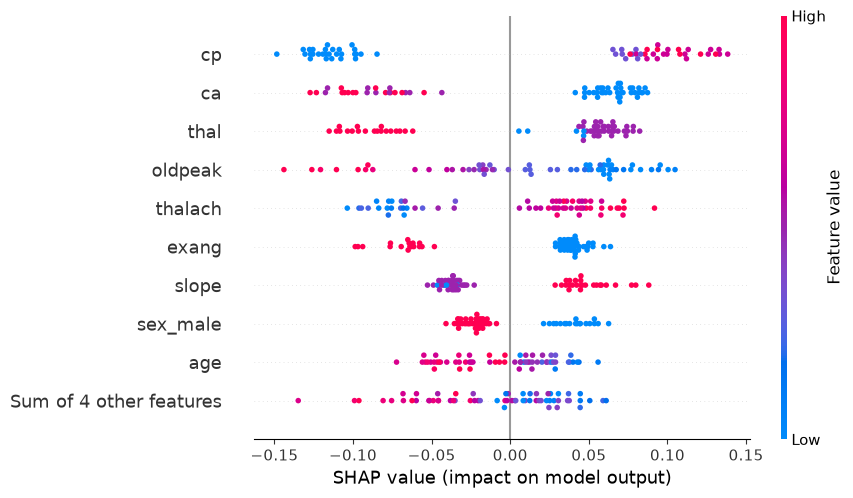

In [119]:
plt.figure(figsize=(12,6))
explainer = shap.TreeExplainer(best_rf)

shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values[:,:,1])


In [120]:
explanation_map = {
    "age": "Higher age increases cardiovascular risk",
    "sex": "Male gender is associated with increased risk",
    "cp": "Chest pain type significantly influences prediction",
    "trestbps": "Elevated resting blood pressure increases risk",
    "chol": "Higher cholesterol contributes to heart disease risk",
    "fbs": "High fasting blood sugar may increase risk",
    "restecg": "Abnormal ECG readings may indicate heart problems",
    "thalach": "Maximum heart rate achieved influences prediction",
    "exang": "Exercise induced angina is a strong indicator",
    "oldpeak": "ST depression indicates cardiac stress",
    "slope": "Slope of ST segment affects prediction",
    "ca": "Number of affected vessels is highly important",
    "thal": "Thalassemia status contributes to prediction"
}

In [121]:
shap_values = explainer(sample)

In [122]:
print(shap_values.values.shape)

(1, 13, 2)


In [123]:
risk_values = shap_values.values[0, :, 1]

In [124]:
feature_df = pd.DataFrame({
    "Feature": sample.columns,
    "SHAP_Value": risk_values
})

In [126]:
feature_df

,Feature,SHAP_Value
0,age,-0.054020
1,cp,0.093643
2,trestbps,0.007065
3,chol,0.022177
4,fbs,-0.000448
5,restecg,-0.009175
6,thalach,0.011069
7,exang,0.037506
8,oldpeak,-0.087420
9,slope,-0.033456


In [127]:
positive_features = feature_df[
    feature_df["SHAP_Value"] > 0
]
positive_features = positive_features.sort_values(
    by="SHAP_Value",
    ascending=False
)

In [128]:
positive_features

,Feature,SHAP_Value
1,cp,0.093643
10,ca,0.081818
7,exang,0.037506
3,chol,0.022177
11,thal,0.011120
6,thalach,0.011069
2,trestbps,0.007065


In [129]:
top_risk_factors = positive_features.head(3)

In [131]:
reasons = []

for feature in top_risk_factors["Feature"]:
    reasons.append(explanation_map[feature])

In [132]:
reasons

['Chest pain type significantly influences prediction',
 'Number of affected vessels is highly important',
 'Exercise induced angina is a strong indicator']

In [134]:
result = {
    "prediction": int(prediction),
    "top_risk_factors": top_risk_factors["Feature"].tolist(),
    "reasons": reasons
}


In [135]:
print(result)

{'prediction': 1, 'top_risk_factors': ['cp', 'ca', 'exang'], 'reasons': ['Chest pain type significantly influences prediction', 'Number of affected vessels is highly important', 'Exercise induced angina is a strong indicator']}


In [137]:
joblib.dump(
    explainer,
    "shap_explainer.pkl"
)

['shap_explainer.pkl']